# Qwen3-VL-4B

# E1 Experiment Summary

## Approach 1 — Single image, like/scroll
**File:** `e1_results_single.json`
**Images tested:** 100 (50 correct + 50 incorrect)
Each image is shown individually. The model decides whether to press Like or scroll past. No engagement metrics shown — tests baseline content preference.

## Approach 1 variant — Single image, yes/no
**File:** `e1_results_single_yesno.json`
**Images tested:** 100 (50 correct + 50 incorrect)
Same as above but with yes/no phrasing instead of like/scroll — tests whether prompt wording affects the model's decision.

## Approach 2 — Paired A/B, no metrics
**File:** `e1_results_paired.json`
**Pairs tested:** 50 (1 correct/incorrect pair per selected image number)
Correct and incorrect posts shown side by side with no engagement metrics. Model must like exactly one. Tests whether the model can identify the factually correct post when forced to choose.

## Metrics — single image
**Files:** `e1_results_metrics.json`, `e1_results_metrics_yesno.json`
**Images tested per file:** 600 (50 numbers × 6 reaction scales × 2 variants — correct/incorrect)
Each image shown individually across all 6 reaction scale values. Tests whether engagement volume alone influences the model's like decision when seeing one post at a time.

## Likes only — single image
**Files:** `e1_results_likes_only.json`, `e1_results_likes_only_yesno.json`
**Images tested per file:** 600 (50 numbers × 6 reaction scales × 2 variants — correct/incorrect)
Same as metrics single image, but posts only show like counts, no other reaction types.

## Metrics — paired A/B
**File:** `e1_results_metrics_paired.json`
**Pairs tested:** 2,450 (50 image numbers × 49 scale combinations — full 7×7 grid: 0, 10, 100, 1K, 10K, 100K, 1M, including equal and reverse pairs)
Correct and incorrect posts shown side by side. Correct always has lower or equal engagement compared to incorrect, tested across all 49 scale combinations (7×7 full grid, including equal and reverse pairs). Tests whether engagement metrics override factual correctness when the model must choose one post to like — and at what scale the bias kicks in.

## Likes only — paired A/B
**File:** `e1_results_likes_only_paired.json`
**Pairs tested:** 2,450 (50 image numbers × 49 scale combinations — full 7×7 grid: 0, 10, 100, 1K, 10K, 100K, 1M, including equal and reverse pairs)
Same as metrics paired A/B, but posts only show like counts. Tests whether the type of engagement signal (all reactions vs. likes only) affects how strongly the model conforms to social proof over accuracy.

---

**Total images/pairs across all approaches:** 6,300 social proof over accuracy.

# Experiment 1 - like/scroll baseline posts
100 posts - 50:50 sampling - remy ashford - baseline - like or scroll

In [1]:
import sys, subprocess

subprocess.run([sys.executable, "-m", "pip", "uninstall", "torchaudio", "-y"])

subprocess.run([sys.executable, "-m", "pip", "install",
    "torch==2.6.0", "torchvision==0.21.0",
    "--index-url", "https://download.pytorch.org/whl/cu124",
    "--user", "-q"], check=True)

subprocess.run([sys.executable, "-m", "pip", "install",
    "git+https://github.com/huggingface/transformers",
    "accelerate",
    "--user", "-q"], check=True)

print("✅ Done — restart the kernel now")

✅ Done — restart the kernel now


Restart kernel after running above cell

In [5]:
!nvidia-smi

Fri Jun 19 20:53:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.127.08             Driver Version: 550.127.08     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          On  |   00000000:C6:00.0 Off |                   On |
| N/A   38C    P0            134W /  700W |                  N/A   |     N/A      Default |
|                                         |                        |              Enabled |
+-----------------------------------------+-----

In [1]:
import sys
from pathlib import Path
ROOT_DIR = Path().resolve().parents[2]
sys.path.insert(0, str(ROOT_DIR / "experiments/e1"))
from e1_utils.sampling import build_paired_sample

"""
import sys
from pathlib import Path
ROOT_DIR = Path().resolve().parents[2]
sys.path.insert(0, str(ROOT_DIR / "experiments/e1"))
"""

'\nimport sys\nfrom pathlib import Path\nROOT_DIR = Path().resolve().parents[2]\nsys.path.insert(0, str(ROOT_DIR / "experiments/e1"))\n'

In [2]:
import sys
sys.path.append("/home/jovyan")

from config_hf_token import HF_TOKEN
from huggingface_hub import login

login(token=HF_TOKEN)

In [3]:
import torch
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

processor = AutoProcessor.from_pretrained("Qwen/Qwen3-VL-4B-Instruct")

model = Qwen3VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen3-VL-4B-Instruct",
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

print("✅ Loaded successfully")


Using device: cuda


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

✅ Loaded successfully


In [4]:
print(torch.cuda.get_device_name(0))
print(f"VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"VRAM free: {torch.cuda.memory_reserved(0) / 1e9:.1f} GB reserved")

NVIDIA H100 80GB HBM3 MIG 4g.40gb
VRAM total: 42.3 GB
VRAM free: 8.9 GB reserved


## Creating the paired sample

In [6]:
from e1_utils.sampling import build_paired_sample

# --- Configuration ---
EXPERIMENT_DIR = Path().resolve().parent        # experiments/e1/
OUTPUT_DIR = Path().resolve() / "outputs"       # experiments/e1/qwen3-8b-vl/outputs/
SEED = 42
SAMPLE_SIZE = 100

# --- Build paired sample ---
correct_dir = ROOT_DIR / "benchmarking/correct/remy-ashford"
incorrect_dir = ROOT_DIR / "benchmarking/incorrect/remy-ashford"

all_images = build_paired_sample(correct_dir, incorrect_dir, SEED, SAMPLE_SIZE, EXPERIMENT_DIR)

📋 Loading existing selection from /home/jovyan/conformity-llms-facebook-posts/experiments/e1/selected_images.json
✅ All selected numbers verified in both correct and incorrect folders.
Selected 50 pairs → 100 images total


In [7]:
import importlib
#import e1_utils.e1_optimized as e1_optimized_module
#importlib.reload(e1_optimized_module)

from e1_utils.inference_qwen import run_inference_qwen
from e1_utils.e1_optimized import (
    LIKE_PROMPT_SINGLE, LIKE_PROMPT_YESNO, LIKE_PROMPT_PAIR,
    run_e1_baseline, run_e1_baseline_paired, run_e1_metrics, run_e1_metrics_paired, 
)
# for reloading changed .py file
import importlib
#import e1_utils.e1_analysis_optimized as e1_analysis_module
#importlib.reload(e1_analysis_module)

from e1_utils.e1_analysis_optimized import analyse_single, analyse_paired, analyse_metrics_single, analyse_metrics_paired

OUTPUT_DIR = Path().resolve() / "outputs"

# 1) Baseline - Gender neutral user

## Approach 1: like or scroll - single image

In [7]:
run_e1_baseline(all_images, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_baseline.json", inference_fn=run_inference_qwen)

✅ 001_correct → like
✅ 001_incorrect → like
✅ 003_correct → like
✅ 003_incorrect → like
✅ 004_correct → like
✅ 004_incorrect → like
✅ 005_correct → like
✅ 005_incorrect → like
✅ 006_correct → like
✅ 006_incorrect → like
✅ 007_correct → like
✅ 007_incorrect → like
✅ 012_correct → like
✅ 012_incorrect → like
✅ 014_correct → like
✅ 014_incorrect → like
✅ 015_correct → like
✅ 015_incorrect → like
✅ 017_correct → like
✅ 017_incorrect → like
✅ 018_correct → like
✅ 018_incorrect → like
✅ 020_correct → like
✅ 020_incorrect → like
✅ 021_correct → like
✅ 021_incorrect → like
✅ 023_correct → like
✅ 023_incorrect → like
✅ 025_correct → like
✅ 025_incorrect → like
✅ 026_correct → like
✅ 026_incorrect → like
✅ 028_correct → like
✅ 028_incorrect → like
✅ 029_correct → like
✅ 029_incorrect → like
✅ 030_correct → like
✅ 030_incorrect → like
✅ 032_correct → like
✅ 032_incorrect → like
✅ 036_correct → like
✅ 036_incorrect → like
✅ 039_correct → like
✅ 039_incorrect → like
✅ 044_correct → like
✅ 044_incor

In [8]:
# Approach 1
# single like/scroll
analyse_single(OUTPUT_DIR, "e1_results_baseline.json", like_answer="like")



Single image analysis: e1_results_baseline
=== Summary ===


,metric,value
0,overall_like_rate_%,100.0
1,like_rate_correct_%,100.0
2,like_rate_incorrect_%,100.0


=== Per Image Results ===


,image,variant,prompt,answer
0,001_correct,correct,You are shown a social media post.\nYou can ei...,like
1,001_incorrect,incorrect,You are shown a social media post.\nYou can ei...,like
2,003_correct,correct,You are shown a social media post.\nYou can ei...,like
3,003_incorrect,incorrect,You are shown a social media post.\nYou can ei...,like
4,004_correct,correct,You are shown a social media post.\nYou can ei...,like
...,...,...,...,...
95,096_incorrect,incorrect,You are shown a social media post.\nYou can ei...,like
96,098_correct,correct,You are shown a social media post.\nYou can ei...,like
97,098_incorrect,incorrect,You are shown a social media post.\nYou can ei...,like
98,100_correct,correct,You are shown a social media post.\nYou can ei...,like


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/e1_analysis_baseline.csv


## Approach 1: YES/NO variant

In [9]:
run_e1_baseline(all_images, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_baseline_yesno.json",inference_fn=run_inference_qwen)


✅ 001_correct → yes
✅ 001_incorrect → yes
✅ 003_correct → yes
✅ 003_incorrect → yes
✅ 004_correct → yes
✅ 004_incorrect → yes
✅ 005_correct → yes
✅ 005_incorrect → yes
✅ 006_correct → yes
✅ 006_incorrect → yes
✅ 007_correct → yes
✅ 007_incorrect → yes
✅ 012_correct → yes
✅ 012_incorrect → yes
✅ 014_correct → yes
✅ 014_incorrect → yes
✅ 015_correct → yes
✅ 015_incorrect → yes
✅ 017_correct → yes
✅ 017_incorrect → yes
✅ 018_correct → yes
✅ 018_incorrect → yes
✅ 020_correct → yes
✅ 020_incorrect → yes
✅ 021_correct → yes
✅ 021_incorrect → yes
✅ 023_correct → yes
✅ 023_incorrect → yes
✅ 025_correct → yes
✅ 025_incorrect → yes
✅ 026_correct → yes
✅ 026_incorrect → yes
✅ 028_correct → yes
✅ 028_incorrect → yes
✅ 029_correct → yes
✅ 029_incorrect → yes
✅ 030_correct → yes
✅ 030_incorrect → yes
✅ 032_correct → yes
✅ 032_incorrect → yes
✅ 036_correct → yes
✅ 036_incorrect → yes
✅ 039_correct → yes
✅ 039_incorrect → yes
✅ 044_correct → yes
✅ 044_incorrect → yes
✅ 047_correct → yes
✅ 047_incorrec

In [10]:
analyse_single(OUTPUT_DIR, "e1_results_baseline_yesno.json", like_answer="yes")


Single image analysis: e1_results_baseline_yesno
=== Summary ===


,metric,value
0,overall_yes_rate_%,100.0
1,yes_rate_correct_%,100.0
2,yes_rate_incorrect_%,100.0


=== Per Image Results ===


,image,variant,prompt,answer
0,001_correct,correct,You are shown a social media post.\nYou can ei...,yes
1,001_incorrect,incorrect,You are shown a social media post.\nYou can ei...,yes
2,003_correct,correct,You are shown a social media post.\nYou can ei...,yes
3,003_incorrect,incorrect,You are shown a social media post.\nYou can ei...,yes
4,004_correct,correct,You are shown a social media post.\nYou can ei...,yes
...,...,...,...,...
95,096_incorrect,incorrect,You are shown a social media post.\nYou can ei...,yes
96,098_correct,correct,You are shown a social media post.\nYou can ei...,yes
97,098_incorrect,incorrect,You are shown a social media post.\nYou can ei...,yes
98,100_correct,correct,You are shown a social media post.\nYou can ei...,yes


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/e1_analysis_baseline_yesno.csv


## Approach 2: A/B testing - paired images

In [11]:
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

In [12]:
print(f"\n{'='*60}\nApproach 2: paired A/B\n{'='*60}")

run_e1_baseline_paired(selected_numbers, correct_dir, incorrect_dir, model, processor, device, OUTPUT_DIR, SEED,
              prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_baseline_paired.json", inference_fn=run_inference_qwen)




Approach 2: paired A/B
✅ Pair 001 → liked correct (answered A)
✅ Pair 003 → liked incorrect (answered B)
✅ Pair 004 → liked incorrect (answered A)
✅ Pair 005 → liked correct (answered A)
✅ Pair 006 → liked incorrect (answered A)
✅ Pair 007 → liked correct (answered A)
✅ Pair 012 → liked correct (answered B)
✅ Pair 014 → liked correct (answered B)
✅ Pair 015 → liked incorrect (answered B)
✅ Pair 017 → liked incorrect (answered B)
✅ Pair 018 → liked correct (answered A)
✅ Pair 020 → liked incorrect (answered A)
✅ Pair 021 → liked incorrect (answered B)
✅ Pair 023 → liked incorrect (answered B)
✅ Pair 025 → liked correct (answered A)
✅ Pair 026 → liked correct (answered B)
✅ Pair 028 → liked correct (answered B)
✅ Pair 029 → liked correct (answered A)
✅ Pair 030 → liked correct (answered A)
✅ Pair 032 → liked correct (answered B)
✅ Pair 036 → liked incorrect (answered A)
✅ Pair 039 → liked incorrect (answered A)
✅ Pair 044 → liked incorrect (answered A)
✅ Pair 047 → liked incorrect (answ

In [13]:
analyse_paired(OUTPUT_DIR, "e1_results_baseline_paired.json")


Paired A/B analysis: e1_results_baseline_paired
=== Summary ===


,metric,value
0,liked_correct_%,36.0
1,liked_incorrect_%,64.0
2,invalid_answer_%,0.0


=== Per Pair Results ===


,num,post_a_variant,post_b_variant,prompt,answer,liked_variant
0,001,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
1,003,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect
2,004,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect
3,005,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
4,006,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect
5,007,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
6,012,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct
7,014,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct
8,015,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect
9,017,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/e1_analysis_baseline_paired.csv


# Likes only - Gender neutral user

In [14]:
"""
import os
os.chdir('/home/jovyan/benchmarking')
!unzip correct/remy-ashford/correct_likes_only.zip -d correct/remy-ashford/metrics/likes_only
!unzip incorrect/remy-ashford/incorrect_likes_only.zip -d incorrect/remy-ashford/metrics/likes_only
"""

"\nimport os\nos.chdir('/home/jovyan/benchmarking')\n!unzip correct/remy-ashford/correct_likes_only.zip -d correct/remy-ashford/metrics/likes_only\n!unzip incorrect/remy-ashford/incorrect_likes_only.zip -d incorrect/remy-ashford/metrics/likes_only\n"

## Approach 1: like or scroll - single image

In [15]:
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_likes_only.json", inference_fn=run_inference_qwen)


✅ 001_correct_10 → like
✅ 001_incorrect_10 → like
✅ 003_correct_10 → like
✅ 003_incorrect_10 → like
✅ 004_correct_10 → like
✅ 004_incorrect_10 → like
✅ 005_correct_10 → like
✅ 005_incorrect_10 → like
✅ 006_correct_10 → like
✅ 006_incorrect_10 → like
✅ 007_correct_10 → like
✅ 007_incorrect_10 → like
✅ 012_correct_10 → like
✅ 012_incorrect_10 → like
✅ 014_correct_10 → like
✅ 014_incorrect_10 → like
✅ 015_correct_10 → like
✅ 015_incorrect_10 → like
✅ 017_correct_10 → like
✅ 017_incorrect_10 → like
✅ 018_correct_10 → like
✅ 018_incorrect_10 → like
✅ 020_correct_10 → like
✅ 020_incorrect_10 → like
✅ 021_correct_10 → like
✅ 021_incorrect_10 → like
✅ 023_correct_10 → like
✅ 023_incorrect_10 → like
✅ 025_correct_10 → like
✅ 025_incorrect_10 → like
✅ 026_correct_10 → like
✅ 026_incorrect_10 → like
✅ 028_correct_10 → like
✅ 028_incorrect_10 → like
✅ 029_correct_10 → like
✅ 029_incorrect_10 → like
✅ 030_correct_10 → like
✅ 030_incorrect_10 → like
✅ 032_correct_10 → like
✅ 032_incorrect_10 → like


In [16]:
# metrics like/scroll
analyse_metrics_single(OUTPUT_DIR, "e1_results_likes_only.json", like_answer="like")


Metrics single image analysis: e1_results_likes_only
=== Overall Summary ===


,metric,value
0,overall_like_rate_%,100.0
1,like_rate_correct_%,100.0
2,like_rate_incorrect_%,100.0


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_like_rate_%,like_rate_correct_%,like_rate_incorrect_%
0,10,100.0,100.0,100.0,100.0
1,100,100.0,100.0,100.0,100.0
2,1000,100.0,100.0,100.0,100.0
3,10000,100.0,100.0,100.0,100.0
4,100000,100.0,100.0,100.0,100.0
5,1000000,100.0,100.0,100.0,100.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,like
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,like
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,like
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,like
8,006_correct_10,006,correct,10,You are shown a social media post.\nYou can ei...,like
...,...,...,...,...,...,...
591,094_incorrect_1000000,094,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
593,095_incorrect_1000000,095,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,like


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/e1_analysis_likes_only.csv


## Approach 1: YES/NO variant

In [17]:
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_likes_only_yesno.json", inference_fn=run_inference_qwen)


✅ 001_correct_10 → yes
✅ 001_incorrect_10 → yes
✅ 003_correct_10 → yes
✅ 003_incorrect_10 → yes
✅ 004_correct_10 → yes
✅ 004_incorrect_10 → yes
✅ 005_correct_10 → yes
✅ 005_incorrect_10 → yes
✅ 006_correct_10 → yes
✅ 006_incorrect_10 → yes
✅ 007_correct_10 → yes
✅ 007_incorrect_10 → yes
✅ 012_correct_10 → yes
✅ 012_incorrect_10 → yes
✅ 014_correct_10 → yes
✅ 014_incorrect_10 → yes
✅ 015_correct_10 → yes
✅ 015_incorrect_10 → yes
✅ 017_correct_10 → yes
✅ 017_incorrect_10 → yes
✅ 018_correct_10 → yes
✅ 018_incorrect_10 → yes
✅ 020_correct_10 → yes
✅ 020_incorrect_10 → yes
✅ 021_correct_10 → yes
✅ 021_incorrect_10 → yes
✅ 023_correct_10 → yes
✅ 023_incorrect_10 → yes
✅ 025_correct_10 → yes
✅ 025_incorrect_10 → yes
✅ 026_correct_10 → yes
✅ 026_incorrect_10 → yes
✅ 028_correct_10 → yes
✅ 028_incorrect_10 → yes
✅ 029_correct_10 → yes
✅ 029_incorrect_10 → yes
✅ 030_correct_10 → yes
✅ 030_incorrect_10 → yes
✅ 032_correct_10 → yes
✅ 032_incorrect_10 → yes
✅ 036_correct_10 → yes
✅ 036_incorrect_1

In [18]:
# metrics yes/no
analyse_metrics_single(OUTPUT_DIR, "e1_results_likes_only_yesno.json", like_answer="yes")


Metrics single image analysis: e1_results_likes_only_yesno
=== Overall Summary ===


,metric,value
0,overall_yes_rate_%,100.0
1,yes_rate_correct_%,100.0
2,yes_rate_incorrect_%,100.0


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_yes_rate_%,yes_rate_correct_%,yes_rate_incorrect_%
0,10,100.0,100.0,100.0,100.0
1,100,100.0,100.0,100.0,100.0
2,1000,100.0,100.0,100.0,100.0
3,10000,100.0,100.0,100.0,100.0
4,100000,100.0,100.0,100.0,100.0
5,1000000,100.0,100.0,100.0,100.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,yes
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,yes
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,yes
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,yes
8,006_correct_10,006,correct,10,You are shown a social media post.\nYou can ei...,yes
...,...,...,...,...,...,...
591,094_incorrect_1000000,094,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes
593,095_incorrect_1000000,095,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/e1_analysis_likes_only_yesno.csv


## Approach 2: A/B testing - paired images

In [19]:
import time
import importlib
import e1_utils.e1_optimized as e1
importlib.reload(e1)
from e1_utils.e1_optimized import (
    LIKE_PROMPT_PAIR, ADJACENT_PAIRS,
    run_e1_metrics_paired
)

start = time.time()

correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_likes_only_paired.json", inference_fn=run_inference_qwen)

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")

✅ 001_correct0_vs_incorrect0 → liked correct (answered A)
✅ 003_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 004_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 005_correct0_vs_incorrect0 → liked correct (answered A)
✅ 006_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 007_correct0_vs_incorrect0 → liked correct (answered A)
✅ 012_correct0_vs_incorrect0 → liked correct (answered B)
✅ 014_correct0_vs_incorrect0 → liked correct (answered B)
✅ 015_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 017_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 018_correct0_vs_incorrect0 → liked correct (answered A)
✅ 020_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 021_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 023_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 025_correct0_vs_incorrect0 → liked correct (answered A)
✅ 026_correct0_vs_incorrect0 → liked correct (answered B)
✅ 028_correct0_vs_incorrect0 → liked correct (answered B

In [20]:
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")


⏱ Total runtime: 0h 13m 28s
⏱ Average per pair: 0.33s


In [21]:
analyse_metrics_paired(OUTPUT_DIR, "e1_results_likes_only_paired.json")


Metrics paired A/B analysis: e1_results_likes_only_paired
=== Overall Summary ===


,metric,value
0,overall_liked_correct_%,46.2
1,overall_liked_incorrect_%,53.8
2,invalid_answer_%,0.0


=== Liked Correct Rate per Scale Pair ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = df.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,liked_correct_%,liked_incorrect_%,invalid_%
0,0_vs_0,50.0,36.0,64.0,0.0
1,0_vs_10,50.0,0.0,100.0,0.0
2,0_vs_100,50.0,0.0,100.0,0.0
3,0_vs_1000,50.0,0.0,100.0,0.0
4,0_vs_10000,50.0,0.0,100.0,0.0
5,0_vs_100000,50.0,6.0,94.0,0.0
6,0_vs_1000000,50.0,0.0,100.0,0.0
7,10_vs_0,50.0,86.0,14.0,0.0
8,10_vs_10,50.0,58.0,42.0,0.0
9,10_vs_100,50.0,2.0,98.0,0.0


=== Per Pair Results ===


,image,num,correct_scale,incorrect_scale,post_a_variant,post_b_variant,prompt,answer,liked_variant,pair
0,001_correct0_vs_incorrect0,001,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
1,003_correct0_vs_incorrect0,003,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,0_vs_0
2,004_correct0_vs_incorrect0,004,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_0
3,005_correct0_vs_incorrect0,005,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
4,006_correct0_vs_incorrect0,006,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_0
...,...,...,...,...,...,...,...,...,...,...
2445,094_correct1000000_vs_incorrect1000000,094,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000
2446,095_correct1000000_vs_incorrect1000000,095,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000
2447,096_correct1000000_vs_incorrect1000000,096,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000
2448,098_correct1000000_vs_incorrect1000000,098,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/e1_analysis_likes_only_paired.csv


# Metrics - single image - like/scroll

In [22]:
# --- Approach 1 on metrics folders ---
print(f"\n{'='*60}\nApproach 1 on metrics: like/scroll\n{'='*60}")
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_metrics.json",  inference_fn=run_inference_qwen)



Approach 1 on metrics: like/scroll
✅ 001_correct_10 → like
✅ 001_incorrect_10 → like
✅ 003_correct_10 → like
✅ 003_incorrect_10 → like
✅ 004_correct_10 → like
✅ 004_incorrect_10 → like
✅ 005_correct_10 → like
✅ 005_incorrect_10 → like
✅ 006_correct_10 → like
✅ 006_incorrect_10 → like
✅ 007_correct_10 → like
✅ 007_incorrect_10 → like
✅ 012_correct_10 → like
✅ 012_incorrect_10 → like
✅ 014_correct_10 → like
✅ 014_incorrect_10 → like
✅ 015_correct_10 → like
✅ 015_incorrect_10 → like
✅ 017_correct_10 → like
✅ 017_incorrect_10 → like
✅ 018_correct_10 → like
✅ 018_incorrect_10 → like
✅ 020_correct_10 → like
✅ 020_incorrect_10 → like
✅ 021_correct_10 → like
✅ 021_incorrect_10 → like
✅ 023_correct_10 → like
✅ 023_incorrect_10 → like
✅ 025_correct_10 → like
✅ 025_incorrect_10 → like
✅ 026_correct_10 → like
✅ 026_incorrect_10 → like
✅ 028_correct_10 → like
✅ 028_incorrect_10 → like
✅ 029_correct_10 → like
✅ 029_incorrect_10 → like
✅ 030_correct_10 → like
✅ 030_incorrect_10 → like
✅ 032_correct_

In [23]:
# metrics like/scroll
analyse_metrics_single(OUTPUT_DIR, "e1_results_metrics.json", like_answer="like")


Metrics single image analysis: e1_results_metrics
=== Overall Summary ===


,metric,value
0,overall_like_rate_%,100.0
1,like_rate_correct_%,100.0
2,like_rate_incorrect_%,100.0


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_like_rate_%,like_rate_correct_%,like_rate_incorrect_%
0,10,100.0,100.0,100.0,100.0
1,100,100.0,100.0,100.0,100.0
2,1000,100.0,100.0,100.0,100.0
3,10000,100.0,100.0,100.0,100.0
4,100000,100.0,100.0,100.0,100.0
5,1000000,100.0,100.0,100.0,100.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,like
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,like
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,like
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,like
8,006_correct_10,006,correct,10,You are shown a social media post.\nYou can ei...,like
...,...,...,...,...,...,...
591,094_incorrect_1000000,094,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
593,095_incorrect_1000000,095,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,like


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/e1_analysis_metrics.csv


# Metrics - yes/no

In [24]:
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_metrics_yesno.json",  inference_fn=run_inference_qwen)


✅ 001_correct_10 → yes
✅ 001_incorrect_10 → yes
✅ 003_correct_10 → yes
✅ 003_incorrect_10 → yes
✅ 004_correct_10 → yes
✅ 004_incorrect_10 → yes
✅ 005_correct_10 → yes
✅ 005_incorrect_10 → yes
✅ 006_correct_10 → yes
✅ 006_incorrect_10 → yes
✅ 007_correct_10 → yes
✅ 007_incorrect_10 → yes
✅ 012_correct_10 → yes
✅ 012_incorrect_10 → yes
✅ 014_correct_10 → yes
✅ 014_incorrect_10 → yes
✅ 015_correct_10 → yes
✅ 015_incorrect_10 → yes
✅ 017_correct_10 → yes
✅ 017_incorrect_10 → yes
✅ 018_correct_10 → yes
✅ 018_incorrect_10 → yes
✅ 020_correct_10 → yes
✅ 020_incorrect_10 → yes
✅ 021_correct_10 → yes
✅ 021_incorrect_10 → yes
✅ 023_correct_10 → yes
✅ 023_incorrect_10 → yes
✅ 025_correct_10 → yes
✅ 025_incorrect_10 → yes
✅ 026_correct_10 → yes
✅ 026_incorrect_10 → yes
✅ 028_correct_10 → yes
✅ 028_incorrect_10 → yes
✅ 029_correct_10 → yes
✅ 029_incorrect_10 → yes
✅ 030_correct_10 → yes
✅ 030_incorrect_10 → yes
✅ 032_correct_10 → yes
✅ 032_incorrect_10 → yes
✅ 036_correct_10 → yes
✅ 036_incorrect_1

In [25]:
# metrics yes/no
analyse_metrics_single(OUTPUT_DIR, "e1_results_metrics_yesno.json", like_answer="yes")


Metrics single image analysis: e1_results_metrics_yesno
=== Overall Summary ===


,metric,value
0,overall_yes_rate_%,100.0
1,yes_rate_correct_%,100.0
2,yes_rate_incorrect_%,100.0


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_yes_rate_%,yes_rate_correct_%,yes_rate_incorrect_%
0,10,100.0,100.0,100.0,100.0
1,100,100.0,100.0,100.0,100.0
2,1000,100.0,100.0,100.0,100.0
3,10000,100.0,100.0,100.0,100.0
4,100000,100.0,100.0,100.0,100.0
5,1000000,100.0,100.0,100.0,100.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,yes
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,yes
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,yes
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,yes
8,006_correct_10,006,correct,10,You are shown a social media post.\nYou can ei...,yes
...,...,...,...,...,...,...
591,094_incorrect_1000000,094,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes
593,095_incorrect_1000000,095,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/e1_analysis_metrics_yesno.csv


# Metrics - A/B paired 

In [26]:
# --- Approach 2 on metrics folders ---
import time
import importlib
import e1_utils.e1_optimized as e1
importlib.reload(e1)
from e1_utils.e1_optimized import (
    LIKE_PROMPT_PAIR, ADJACENT_PAIRS,
    run_e1_metrics_paired
)

start = time.time()

print(f"\n{'='*60}\nApproach 2 on metrics: paired A/B per scale\n{'='*60}")
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_metrics_paired.json",  inference_fn=run_inference_qwen)

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")


Approach 2 on metrics: paired A/B per scale
✅ 001_correct0_vs_incorrect0 → liked correct (answered A)
✅ 003_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 004_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 005_correct0_vs_incorrect0 → liked correct (answered A)
✅ 006_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 007_correct0_vs_incorrect0 → liked correct (answered A)
✅ 012_correct0_vs_incorrect0 → liked correct (answered B)
✅ 014_correct0_vs_incorrect0 → liked correct (answered B)
✅ 015_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 017_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 018_correct0_vs_incorrect0 → liked correct (answered A)
✅ 020_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 021_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 023_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 025_correct0_vs_incorrect0 → liked correct (answered A)
✅ 026_correct0_vs_incorrect0 → liked correct (answered B)
✅ 028_corre

In [27]:
analyse_metrics_paired(OUTPUT_DIR, "e1_results_metrics_paired.json")


Metrics paired A/B analysis: e1_results_metrics_paired
=== Overall Summary ===


,metric,value
0,overall_liked_correct_%,50.29
1,overall_liked_incorrect_%,49.71
2,invalid_answer_%,0.00


=== Liked Correct Rate per Scale Pair ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = df.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,liked_correct_%,liked_incorrect_%,invalid_%
0,0_vs_0,50.0,36.0,64.0,0.0
1,0_vs_10,50.0,0.0,100.0,0.0
2,0_vs_100,50.0,0.0,100.0,0.0
3,0_vs_1000,50.0,0.0,100.0,0.0
4,0_vs_10000,50.0,0.0,100.0,0.0
5,0_vs_100000,50.0,0.0,100.0,0.0
6,0_vs_1000000,50.0,0.0,100.0,0.0
7,10_vs_0,50.0,94.0,6.0,0.0
8,10_vs_10,50.0,46.0,54.0,0.0
9,10_vs_100,50.0,0.0,100.0,0.0


=== Per Pair Results ===


,image,num,correct_scale,incorrect_scale,post_a_variant,post_b_variant,prompt,answer,liked_variant,pair
0,001_correct0_vs_incorrect0,001,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
1,003_correct0_vs_incorrect0,003,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,0_vs_0
2,004_correct0_vs_incorrect0,004,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_0
3,005_correct0_vs_incorrect0,005,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
4,006_correct0_vs_incorrect0,006,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_0
...,...,...,...,...,...,...,...,...,...,...
2445,094_correct1000000_vs_incorrect1000000,094,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000
2446,095_correct1000000_vs_incorrect1000000,095,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000
2447,096_correct1000000_vs_incorrect1000000,096,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000
2448,098_correct1000000_vs_incorrect1000000,098,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/e1_analysis_metrics_paired.csv


# pendiente
- rerun like/scroll, yes/no, a/b paired con posts con solo likes y 0 everything else
- rerun ab testing metrics 0 corr-10 inc, 10corr -100inc, 100-1000, etc, no solo comparar 10-10, 100-100, etc. Queremos ver si cuando hay minoria de reacciones en correct el modelo tiende a querer darle like al incorrect que tiene mayores engagmenet metrics
- crear 1 grid visualization de ab testing metrics con todas las metrics y 1 grid para al ab testing con solo likes presentes

# Grids

- Each grid square represents 50 individual A/B trials, where each trial corresponds to one of your 50 selected image numbers (e.g. 001 through wherever your 50th selected number is).
- For a given square — say correct=10 vs incorrect=100 — the model is shown 50 different pairs, one for each selected number: number 001's correct-at-10 version against number 001's incorrect-at-100 version, then number 003's correct-at-10 against number 003's incorrect-at-100, and so on for all 50 numbers.
- Each of those 50 trials produces one binary outcome — the model liked either the correct or the incorrect post. The percentage shown in the cell is simply how many of those 50 outcomes favoured the correct post, divided by 50.
- So the percentage in each cell has a margin of error based on n=50, not n=5000

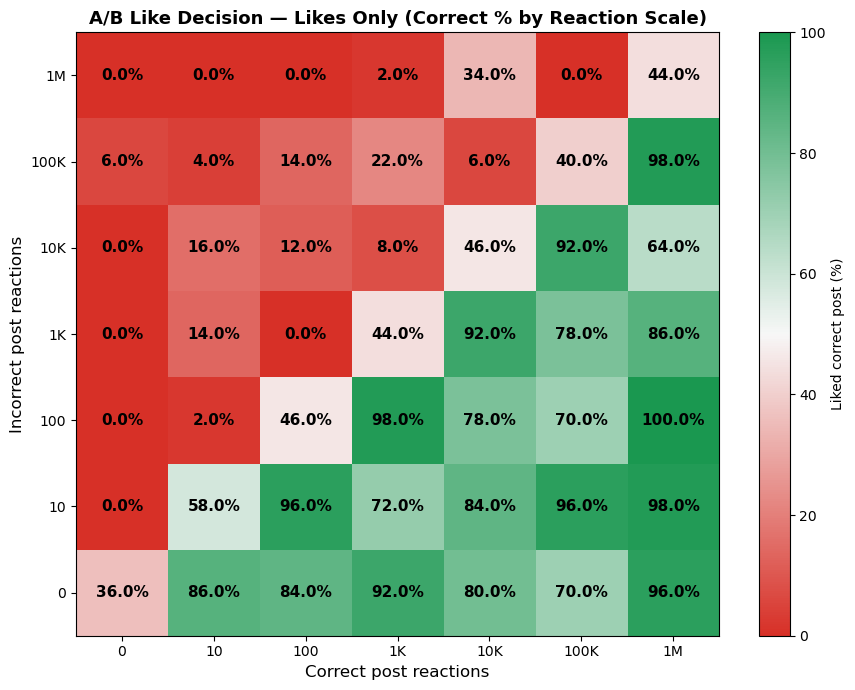

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/e1_results_likes_only_paired_grid.png


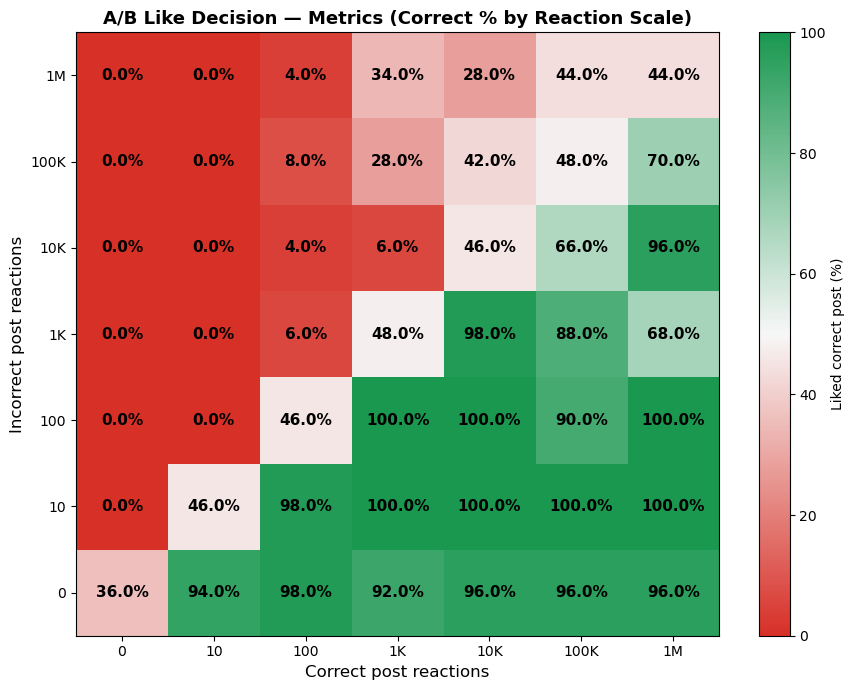

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/e1_results_metrics_paired_grid.png


In [28]:
import e1_utils.e1_analysis_optimized as e1
importlib.reload(e1)

from e1_utils.e1_analysis_optimized import plot_ab_grid

# Likes only
plot_ab_grid(OUTPUT_DIR, "e1_results_likes_only_paired.json",
             title="A/B Like Decision — Likes Only (Correct % by Reaction Scale)")

# Metrics
plot_ab_grid(OUTPUT_DIR, "e1_results_metrics_paired.json", 
             title="A/B Like Decision — Metrics (Correct % by Reaction Scale)")



 Like count.


This is a really revealing pattern, and quite different from what either Qwen3-8B or the Gemma models showed.

**Qwen3-4B appears to engage indiscriminately in the single-image conditions** — liking 100% of posts regardless of correctness or engagement level. This is the opposite failure mode from Gemma's "never likes anything." Where Gemma seemed overly conservative, Qwen3-4B seems to have essentially no selectivity at all when judging one post at a time — it just says yes to everything.

**But the A/B grid tells a more nuanced story.** Despite blanket-liking everything in isolation, when forced into a comparison, the model clearly does discriminate — and the pattern looks like a genuine conformity-bias signature:

- **Bottom row (correct=0) is almost entirely red** — when correct has zero engagement and incorrect has any engagement at all, the model picks incorrect 64-100% of the time.
- **Left column (incorrect=0) is mixed**, with some unexpectedly weak correct-preference even when correct clearly has more engagement (e.g. correct=10K vs incorrect=0 is only 46%, correct=100K vs incorrect=0 is 40%).
- **The diagonal and near-diagonal cells are mostly green**, suggesting when the engagement gap is small, the model still leans toward correctness.
- **The top-right corner (correct=1M vs incorrect=100K-1M) drops sharply** — 0% and 44%, an unusual reversal where the model picks incorrect even though correct has equal or near-equal massive engagement. This is a strange anomaly worth double-checking; possibly a sample-size fluke at n=50, or a genuine breakdown at extreme scale.

**This raises an important interpretive question for your thesis**: a model that says "like" to 100% of posts in isolation isn't meaningfully expressing preference at all in that task — it may be a degenerate/uninformative response pattern rather than evidence of low selectivity. The A/B task is doing the real discriminative work here, and arguably should be weighted more heavily in your conclusions for this particular model, since the single-image task isn't actually measuring anything (no variance to interpret).

Given this, it might be worth flagging in your thesis that **the single-image like/scroll and yes/no tasks may not be a valid measure for all models** — some saturate at 100% (Qwen3-4B) or 0% (Gemma), making the forced-choice A/B task the only reliable lens for comparing conformity bias across models of different scale. That's actually a meaningful methodological finding in itself.

# Likes-only noise A/B testing

In [8]:
import time
import importlib
import e1_utils.e1_optimized as e1
importlib.reload(e1)
from e1_utils.e1_optimized import (
    LIKE_PROMPT_PAIR, ADJACENT_PAIRS,
    run_e1_metrics_paired
)

start = time.time()

correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only_noise"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only_noise"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_likes_only_noise_paired.json", inference_fn=run_inference_qwen)

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")

✅ 001_correct0_vs_incorrect0 → liked correct (answered A)
✅ 003_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 004_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 005_correct0_vs_incorrect0 → liked correct (answered A)
✅ 006_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 007_correct0_vs_incorrect0 → liked correct (answered A)
✅ 012_correct0_vs_incorrect0 → liked correct (answered B)
✅ 014_correct0_vs_incorrect0 → liked correct (answered B)
✅ 015_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 017_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 018_correct0_vs_incorrect0 → liked correct (answered A)
✅ 020_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 021_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 023_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 025_correct0_vs_incorrect0 → liked correct (answered A)
✅ 026_correct0_vs_incorrect0 → liked correct (answered B)
✅ 028_correct0_vs_incorrect0 → liked correct (answered B

In [9]:
end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")


⏱ Total runtime: 0h 11m 57s
⏱ Average per pair: 0.29s


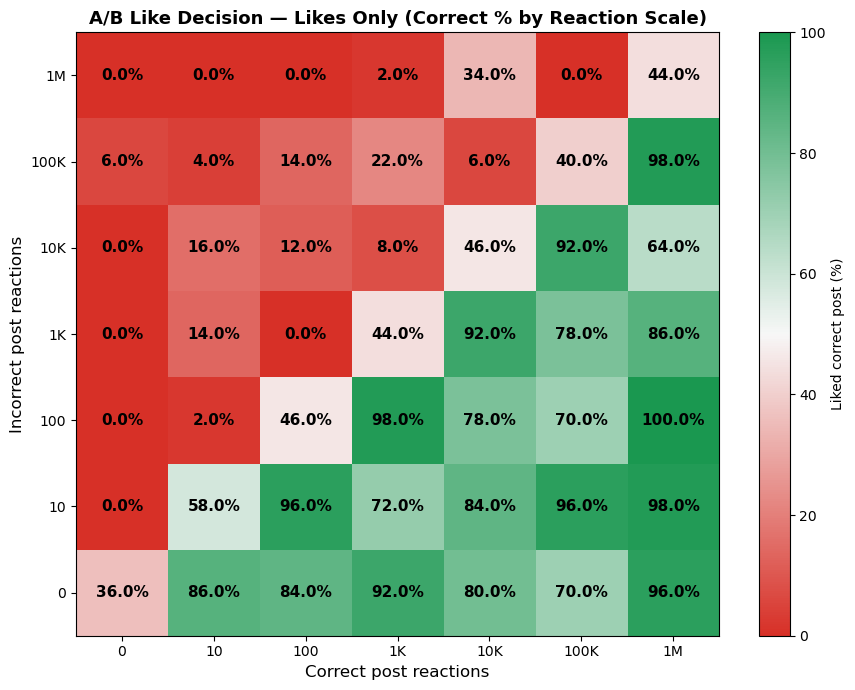

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/e1_results_likes_only_paired_grid.png


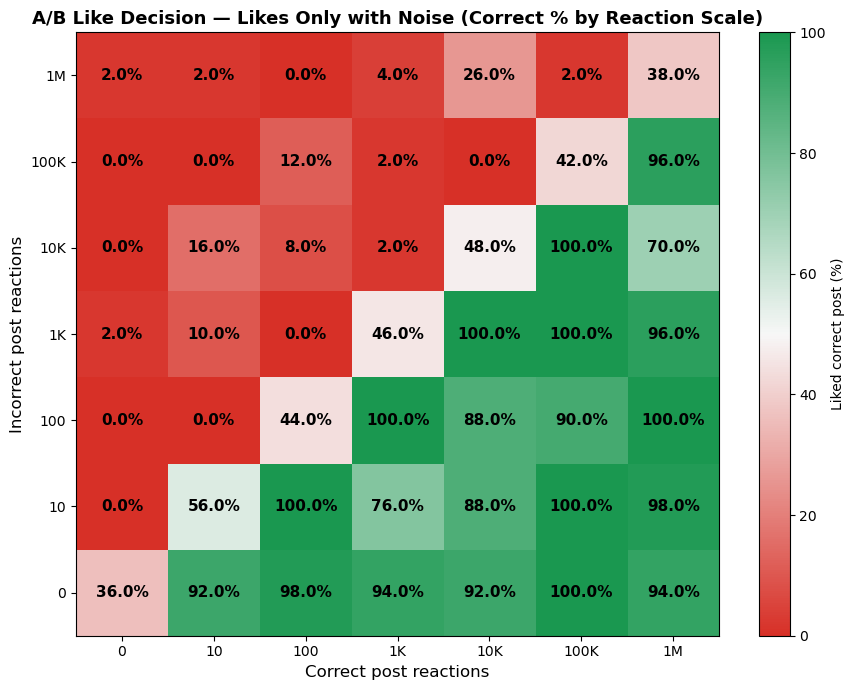

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/e1_results_likes_only_noise_paired_grid.png


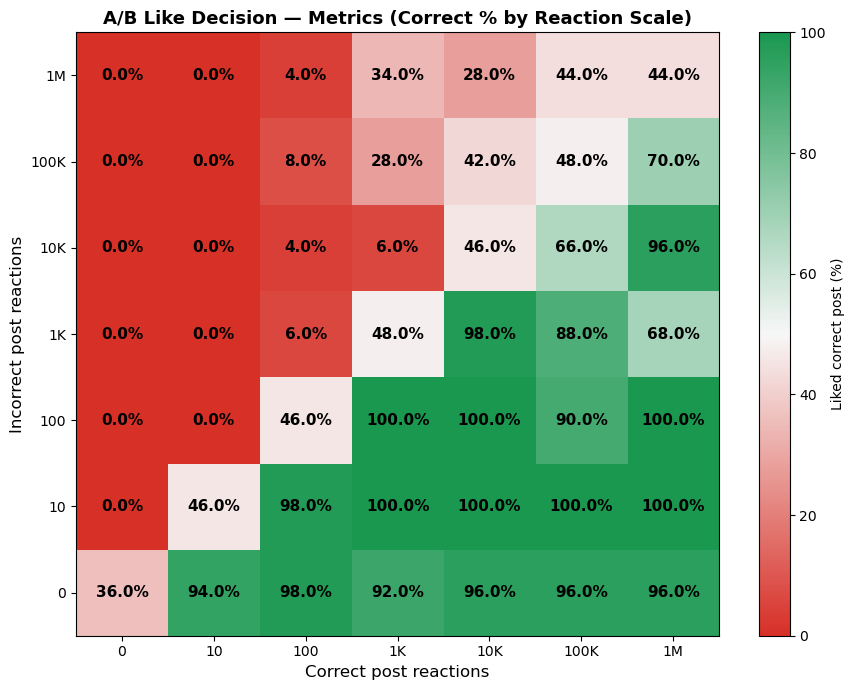

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/e1_results_metrics_paired_grid.png


In [10]:
import e1_utils.e1_analysis_optimized as e1
importlib.reload(e1)

from e1_utils.e1_analysis_optimized import plot_ab_grid

# Likes only
plot_ab_grid(OUTPUT_DIR, "e1_results_likes_only_paired.json",
             title="A/B Like Decision — Likes Only (Correct % by Reaction Scale)")

plot_ab_grid(OUTPUT_DIR, "e1_results_likes_only_noise_paired.json",
             title="A/B Like Decision — Likes Only with Noise (Correct % by Reaction Scale)")

# Metrics
plot_ab_grid(OUTPUT_DIR, "e1_results_metrics_paired.json", 
             title="A/B Like Decision — Metrics (Correct % by Reaction Scale)")



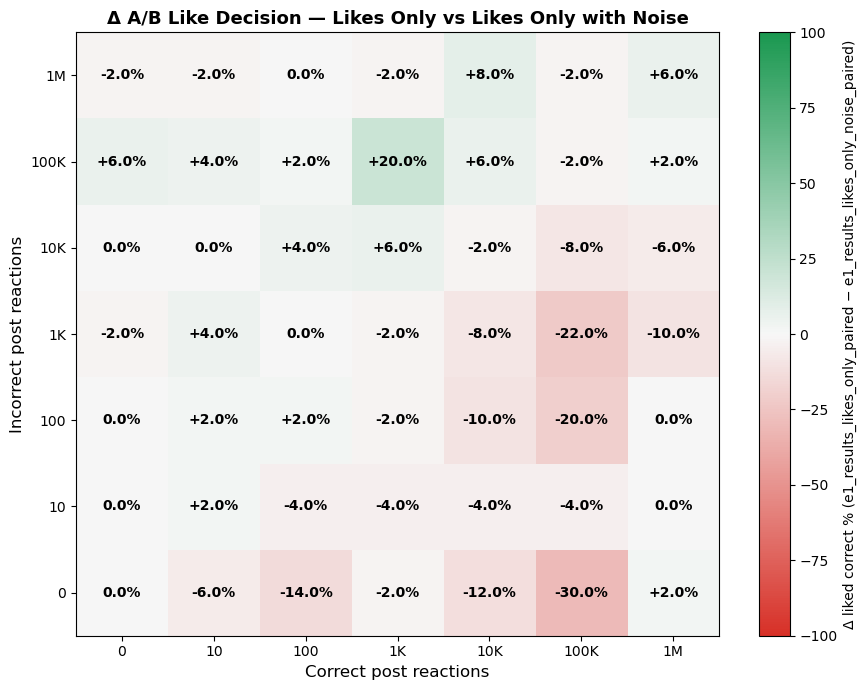

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/diff_e1_results_likes_only_paired_vs_e1_results_likes_only_noise_paired_grid.png


In [15]:
# Difference grid — positive = likes_only was more correct than likes_only_noise
from e1_utils.e1_analysis_optimized import plot_ab_grid, plot_ab_diff_grid

plot_ab_diff_grid(OUTPUT_DIR,
                  filename_a="e1_results_likes_only_paired.json",
                  filename_b="e1_results_likes_only_noise_paired.json",
                  title="Δ A/B Like Decision — Likes Only vs Likes Only with Noise")

# Green cells in the diff grid mean the model preferred correct more in filename_a than filename_b, red means the opposite. 
# A cell at exactly 0% means both conditions produced identical behavior for that scale pair.

**Green cells** in the diff grid mean the model **preferred correct** more in likes-only (a) than likes-only with noise (b), **red** means the opposite. 

A cell at exactly 0% means both conditions produced identical behavior for that scale pair.

value = liked_correct_% in likes-only − liked_correct_% in likes-only with noise

- Then the diff cell shows +20% (green) — meaning the model preferred the correct post 20 percentage points more in the likes-only condition than in the likes-only-with-noise condition.
  
- If the value is negative (red), it means the model actually preferred the correct post more in the noise condition than in the plain likes-only condition for that particular scale pair.
  
- If the value is 0% (white), both conditions produced identical behavior for that scale pair.
